In [1]:
# ============================================
# CELL 1: INSTALL & IMPORT LIBRARIES
# ============================================

# Uncomment nếu bạn chưa cài đặt các thư viện cần thiết
# !pip install lightgbm pyarrow polars

import gc
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import timedelta
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# ============================================
# CELL 2: CONFIG
# ============================================

DATA_PATH = Path(r"/content/drive/MyDrive/Personal project/Paper/sales_train_evaluation.csv")
MAX_LAGS = 1912
LAST_D = 1913
HORIZON = 28

VALID_DATE = "2016-04-25"
TEST_DATE = "2016-03-28"

STATE = "CA"
FORECAST_DAYS = 28

LGB_PARAMS = {
    "objective": "tweedie",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "tweedie_variance_power": 1.2,
    "learning_rate": 0.075,
    "num_leaves": 2047,
    "min_data_in_leaf": 4095,
    "feature_fraction": 0.5,
    "subsample": 0.7,
    "subsample_freq": 1,
    "max_bin": 100,
    "verbosity": -1,
    "seed": 42
}

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# =================================================
# CELL 3: LOAD DATA (Đường dẫn chuẩn theo ảnh)
# =================================================

#calendar = pd.read_csv(r"/content/drive/MyDrive/Paper/calendar.csv")
#prices = pd.read_csv(r"/content/drive/MyDrive/Paper/sell_prices.csv")
#sales = pd.read_csv(r"/content/drive/MyDrive/Paper/sales_train_evaluation.csv")

calendar = pd.read_csv(r"/content/drive/MyDrive/Personal project/Paper/calendar.csv")
prices = pd.read_csv(r"/content/drive/MyDrive/Personal project/Paper/sell_prices.csv")
sales = pd.read_csv(r"/content/drive/MyDrive/Personal project/Paper/sales_train_evaluation.csv")

print("Calendar shape:", calendar.shape)
print("Prices shape:", prices.shape)
print("Sales shape:", sales.shape)

Calendar shape: (1969, 14)
Prices shape: (6841121, 4)
Sales shape: (30490, 1947)


In [5]:
# ============================================
# CELL 4: MEMORY REDUCTION
# ============================================

def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == "int":
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                else:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                else:
                    df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage().sum() / 1024**2
    print(f"Memory usage: {start_mem:.2f} MB -> {end_mem:.2f} MB")
    return df

calendar = reduce_mem_usage(calendar)
prices = reduce_mem_usage(prices)
sales = reduce_mem_usage(sales)

Memory usage: 0.21 MB -> 0.12 MB
Memory usage: 208.77 MB -> 130.48 MB
Memory usage: 452.91 MB -> 96.13 MB


In [6]:
# ============================================
# CELL 5: FILTER STORE
# ============================================

stores = {
    "CA": ["CA_1", "CA_2", "CA_3", "CA_4"],
    "TX": ["TX_1", "TX_2", "TX_3"],
    "WI": ["WI_1", "WI_2", "WI_3"]
}

STORE_ID = "CA_1"
sales_store = sales[sales["store_id"] == STORE_ID]
print("Filtered store shape:", sales_store.shape)

Filtered store shape: (3049, 1947)


In [7]:
# ============================================
# CELL 6: WIDE TO LONG
# ============================================

id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

sales_long = sales_store.melt(
    id_vars=id_cols,
    var_name="d",
    value_name="sales"
)

sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [8]:
# ============================================
# CELL 7: MERGE DATA
# ============================================

calendar["date"] = pd.to_datetime(calendar["date"])

sales_long = sales_long.merge(calendar, on="d", how="left")
sales_long = sales_long.merge(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")

# Dọn dẹp RAM sau khi merge diện rộng
gc.collect()

sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN


In [9]:
# ============================================
# CELL 8: DATE FEATURES
# ============================================

sales_long["day"] = sales_long["date"].dt.day
sales_long["week"] = sales_long["date"].dt.isocalendar().week.astype(np.int32)
sales_long["month"] = sales_long["date"].dt.month
sales_long["year"] = sales_long["date"].dt.year
sales_long["weekday"] = sales_long["date"].dt.weekday

sales_long["is_weekend"] = (sales_long["weekday"] >= 5).astype(np.int8)

sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,day,week,is_weekend
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,NaN,0,0,0,NaN,29,4,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,NaN,0,0,0,NaN,29,4,1
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,NaN,0,0,0,NaN,29,4,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,NaN,0,0,0,NaN,29,4,1
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,NaN,0,0,0,NaN,29,4,1


In [10]:
# ============================================
# CELL 9: LAG FEATURES
# ============================================

# Sắp xếp theo id và date để đảm bảo lag shift chính xác theo dòng thời gian
sales_long = sales_long.sort_values(by=["id", "date"]).reset_index(drop=True)

LAGS = [7, 14, 28]
for lag in LAGS:
    sales_long[f"lag_{lag}"] = sales_long.groupby("id")["sales"].shift(lag)

sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,snap_CA,snap_TX,snap_WI,sell_price,day,week,is_weekend,lag_7,lag_14,lag_28
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,0,0,0,2.0,29,4,1,NaN,NaN,NaN
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,...,0,0,0,2.0,30,4,1,NaN,NaN,NaN
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,...,0,0,0,2.0,31,5,0,NaN,NaN,NaN
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,...,1,1,0,2.0,1,5,0,NaN,NaN,NaN
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,...,1,0,1,2.0,2,5,0,NaN,NaN,NaN


In [11]:
# ============================================
# CELL 10: ROLLING FEATURES
# ============================================

WINDOWS = [7, 14, 28]
for window in WINDOWS:
    # shift(28) tránh rò rỉ dữ liệu (data leakage) khi dự báo chu kỳ 28 ngày
    sales_long[f"rmean_{window}"] = (
        sales_long.groupby("id")["sales"]
        .transform(lambda x: x.shift(28).rolling(window).mean())
    )
    sales_long[f"rstd_{window}"] = (
        sales_long.groupby("id")["sales"]
        .transform(lambda x: x.shift(28).rolling(window).std())
    )

sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,is_weekend,lag_7,lag_14,lag_28,rmean_7,rstd_7,rmean_14,rstd_14,rmean_28,rstd_28
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# ============================================
# CELL 11: PRICE FEATURES
# ============================================

sales_long["price_change"] = sales_long.groupby("id")["sell_price"].pct_change()
sales_long["price_max"] = sales_long.groupby("id")["sell_price"].transform("max")
sales_long["price_norm"] = sales_long["sell_price"] / sales_long["price_max"]

sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,lag_28,rmean_7,rstd_7,rmean_14,rstd_14,rmean_28,rstd_28,price_change,price_max,price_norm
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.240234,0.892578
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.240234,0.892578
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.240234,0.892578
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.240234,0.892578
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.240234,0.892578


In [13]:
# ============================================
# CELL 12: ENCODING
# ============================================

from sklearn.preprocessing import LabelEncoder

cat_cols = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2",
]

for col in cat_cols:
    # Fill NaN with a placeholder string to ensure LabelEncoder can process it
    # and then apply Label Encoding to convert strings to unique integers
    sales_long[col] = sales_long[col].fillna("NoEvent")
    le = LabelEncoder()
    sales_long[col] = le.fit_transform(sales_long[col])

# Additionally, fill NaNs for numerical features that might have been introduced
# by lag, rolling, or price feature engineering. Filling with 0 is a common strategy.
numerical_cols_with_nans = [
    'sell_price', 'price_change', 'price_max', 'price_norm',
    'lag_7', 'lag_14', 'lag_28',
    'rmean_7', 'rstd_7', 'rmean_14', 'rstd_14', 'rmean_28', 'rstd_28'
]

for col in numerical_cols_with_nans:
    if col in sales_long.columns:
        sales_long[col] = sales_long[col].fillna(0) # Filling with 0

sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,lag_28,rmean_7,rstd_7,rmean_14,rstd_14,rmean_28,rstd_28,price_change,price_max,price_norm
0,FOODS_1_001_CA_1_evaluation,0,0,0,0,0,d_1,3,2011-01-29,11101,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.240234,0.892578
1,FOODS_1_001_CA_1_evaluation,0,0,0,0,0,d_2,0,2011-01-30,11101,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.240234,0.892578
2,FOODS_1_001_CA_1_evaluation,0,0,0,0,0,d_3,0,2011-01-31,11101,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.240234,0.892578
3,FOODS_1_001_CA_1_evaluation,0,0,0,0,0,d_4,1,2011-02-01,11101,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.240234,0.892578
4,FOODS_1_001_CA_1_evaluation,0,0,0,0,0,d_5,4,2011-02-02,11101,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.240234,0.892578


In [14]:
# ============================================
# CELL 13: TRAIN VALID SPLIT
# ============================================

# Đảm bảo định dạng datetime đồng nhất để lọc dữ liệu chính xác
train_data = sales_long[sales_long["date"] < pd.to_datetime(TEST_DATE)]
valid_data = sales_long[(sales_long["date"] >= pd.to_datetime(TEST_DATE)) & (sales_long["date"] < pd.to_datetime(VALID_DATE))]

FEATURES = [
    col for col in sales_long.columns
    if col not in ["sales", "date", "d", "id"]
]

X_train = train_data[FEATURES]
y_train = train_data["sales"]

X_valid = valid_data[FEATURES]
y_valid = valid_data["sales"]

# Explicitly convert the problematical categorical columns to int32
# This ensures LightGBM receives numerical data as expected.
problematic_cat_cols = [col for col in ["event_name_1", "event_type_1", "event_name_2", "event_type_2"] if col in FEATURES]
for col in problematic_cat_cols:
    X_train[col] = X_train[col].astype(np.int32)
    X_valid[col] = X_valid[col].astype(np.int32)

print("Train shape:", X_train.shape)
print("Validation shape:", X_valid.shape)

Train shape: (5747365, 33)
Validation shape: (85372, 33)


In [15]:
# ============================================
# CELL 14: TRAIN LIGHTGBM
# ============================================

# Define categorical features explicitly for LightGBM
categorical_features = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2",
]

train_dataset = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
valid_dataset = lgb.Dataset(X_valid, label=y_valid, categorical_feature=categorical_features)

model = lgb.train(
    params=LGB_PARAMS,
    train_set=train_dataset,
    valid_sets=[train_dataset, valid_dataset],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(100)
    ]
)

Training until validation scores don't improve for 100 rounds
[100]	training's rmse: 2.3274	valid_1's rmse: 2.11483
Early stopping, best iteration is:
[50]	training's rmse: 2.40806	valid_1's rmse: 2.10257


In [16]:
# ============================================
# CELL 15: VALIDATION PREDICTION
# ============================================

preds = model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, preds))
print("Validation RMSE:", rmse)

Validation RMSE: 2.1025727615919454


In [17]:
import pickle

# Save model
model.save_model("lgb_model.txt")

# Save X_valid, FEATURES, valid_data
import pickle
with open("shap_data.pkl", "wb") as f:
    pickle.dump({
        "X_valid": X_valid,
        "valid_data": valid_data[["id", "item_id", "dept_id", "cat_id", "date"]],
        "FEATURES": FEATURES
    }, f)

print("✅ Saved lgb_model.txt + shap_data.pkl")

✅ Saved lgb_model.txt + shap_data.pkl


In [18]:
import os
import shutil # Import shutil for copying files

from google.colab import drive
drive.mount('/drive')

import pickle

# Define the full path for the LightGBM model in Google Drive
lgbm_drive_path = r"/content/drive/MyDrive/Personal project/Paper/lgb_model.txt"
# Define a temporary local path for the LightGBM model
lgbm_local_path = "lgb_model.txt"

# Define the full path for the pickle file in Google Drive
shap_drive_path = r"/content/drive/MyDrive/Personal project/Paper/shap_data.pkl"
# Define a temporary local path for the pickle file
shap_local_path = "shap_data.pkl"


# --- Save LightGBM model ---
# First, save to a local temporary path
try:
    model.save_model(lgbm_local_path)
    print(f"LightGBM model saved successfully to local path: {lgbm_local_path}")
    # Then, copy from local to Google Drive
    # Ensure the target directory in Drive exists
    os.makedirs(os.path.dirname(lgbm_drive_path), exist_ok=True)
    shutil.copy(lgbm_local_path, lgbm_drive_path)
    print(f"LightGBM model copied to Google Drive: {lgbm_drive_path}")
except Exception as e:
    print(f"Error saving or copying LightGBM model: {e}")

# --- Save X_valid, FEATURES, valid_data ---
# First, save to a local temporary path
try:
    with open(shap_local_path, "wb") as f:
        pickle.dump({
            "X_valid": X_valid,
            "valid_data": valid_data[["id", "item_id", "dept_id", "cat_id", "date"]],
            "FEATURES": FEATURES
        }, f)
    print(f"SHAP data saved successfully to local path: {shap_local_path}")
    # Then, copy from local to Google Drive
    # Ensure the target directory in Drive exists
    os.makedirs(os.path.dirname(shap_drive_path), exist_ok=True)
    shutil.copy(shap_local_path, shap_drive_path)
    print(f"SHAP data copied to Google Drive: {shap_drive_path}")
except Exception as e:
    print(f"Error saving or copying SHAP data: {e}")

print("✅ Saving process completed!")

Mounted at /drive
LightGBM model saved successfully to local path: lgb_model.txt
Error saving or copying LightGBM model: [Errno 107] Transport endpoint is not connected: '/content/drive/MyDrive'
SHAP data saved successfully to local path: shap_data.pkl
Error saving or copying SHAP data: [Errno 107] Transport endpoint is not connected: '/content/drive/MyDrive'
✅ Saving process completed!


In [19]:
import os
print(os.path.exists("lgb_model.txt"))   # phải ra True
print(os.path.exists("shap_data.pkl"))   # phải ra True

True
True


In [20]:
# ============================================
# CELL 16: FEATURE IMPORTANCE
# ============================================

importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.feature_importance()
})

importance = importance.sort_values(by="importance", ascending=False)
importance.head(30)

,feature,importance
0,item_id,2887
17,sell_price,2752
5,wm_yr_wk,2492
18,day,2392
19,week,2175
28,rmean_28,2061
1,dept_id,1518
31,price_max,1506
6,weekday,1439
27,rstd_14,1425


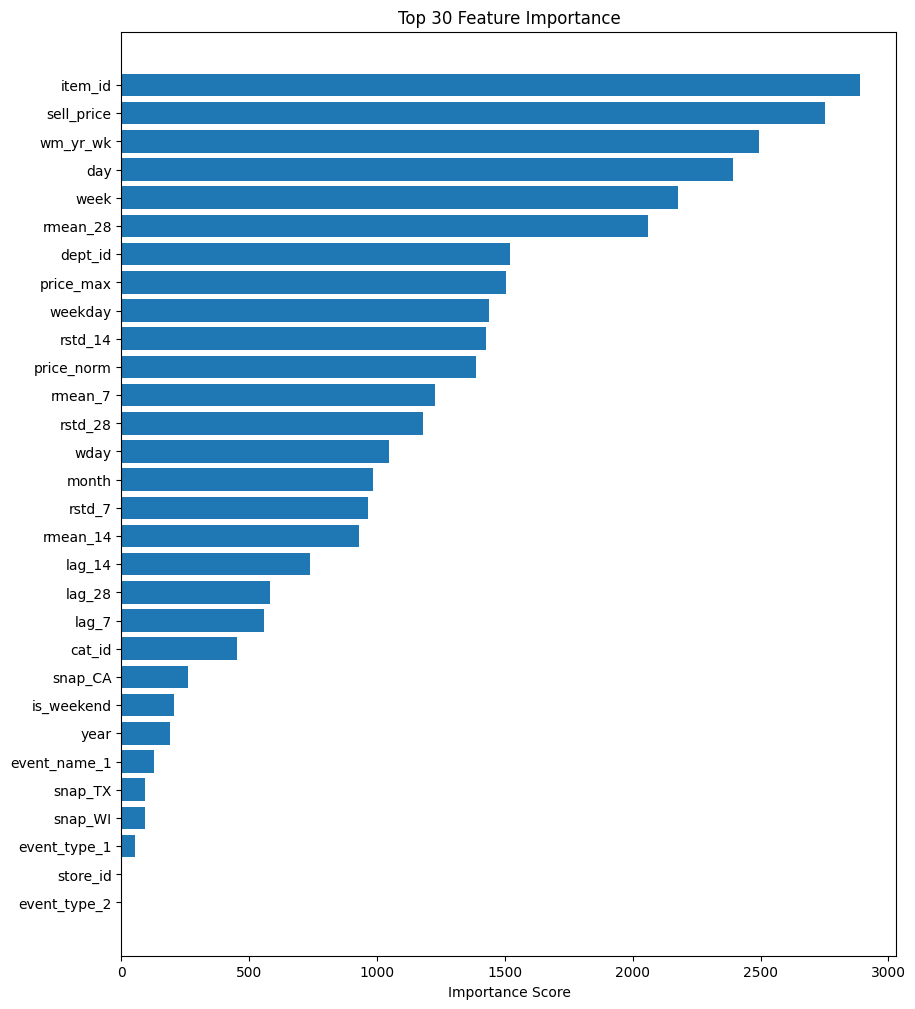

In [21]:
# ============================================
# CELL 17: PLOT IMPORTANCE
# ============================================

top_imp = importance.head(30)

plt.figure(figsize=(10, 12))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Top 30 Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [22]:
# ============================================
# CELL 18: RECURSIVE FORECAST (FIXED)
# ============================================

# Use a copy of the sales_long with all historical data which already has features calculated and encoded
full_df = sales_long.copy()

# Create 28-day forecast period
future_dates = pd.date_range(start=VALID_DATE, periods=28)

# ============================================
# CREATE FUTURE ROWS FOR FORECAST PERIOD
# ============================================

# 1. Get unique IDs from the full dataset
unique_ids = full_df["id"].unique()

# 2. Create a DataFrame for all future (id, date) combinations
future_forecast_rows = pd.DataFrame({
    "id": np.repeat(unique_ids, len(future_dates)),
    "date": np.tile(future_dates, len(unique_ids))
})

# 3. Merge metadata (item_id, dept_id, cat_id, store_id, state_id)
meta_cols = [
    "id", "item_id", "dept_id",
    "cat_id", "store_id", "state_id"
]
# Use meta_data from the original `sales_store` to ensure original string values
# for merging with the `prices` DataFrame later. `sales_store` contains the unencoded strings.
original_id_mapping_df = sales_store[meta_cols].drop_duplicates(subset=["id"])
future_forecast_rows = future_forecast_rows.merge(original_id_mapping_df, on="id", how="left")

# 4. Merge calendar features (including 'd', 'wm_yr_wk', 'event' and 'snap' related columns)
calendar_cols_to_merge = [
    "date", "d", "wm_yr_wk", "weekday", "wday", "month", "year",
    "event_name_1", "event_type_1", "event_name_2", "event_type_2",
    "snap_CA", "snap_TX", "snap_WI"
]
# Ensure calendar 'date' column is datetime before merging
calendar["date"] = pd.to_datetime(calendar["date"])
future_forecast_rows = future_forecast_rows.merge(calendar[calendar_cols_to_merge], on="date", how="left")

# FIX: Convert 'weekday' to integer after merge for future_forecast_rows
# The calendar merges 'weekday' as string, but for 'is_weekend' it needs to be numeric.
future_forecast_rows["weekday"] = future_forecast_rows["date"].dt.weekday

# 5. Merge sell_price features
prices_cols_to_merge = ["store_id", "item_id", "wm_yr_wk", "sell_price"]
future_forecast_rows = future_forecast_rows.merge(prices[prices_cols_to_merge], on=["store_id", "item_id", "wm_yr_wk"], how="left")

# 6. Generate additional date and price features that might be in FEATURES list
# Some of these are already from calendar, but recalculating/ensuring for consistency
future_forecast_rows["day"] = future_forecast_rows["date"].dt.day
future_forecast_rows["week"] = future_forecast_rows["date"].dt.isocalendar().week.astype(np.int32)
future_forecast_rows["is_weekend"] = (future_forecast_rows["weekday"] >= 5).astype(np.int8)

# Price features derived from sell_price
future_forecast_rows["price_change"] = future_forecast_rows.groupby("id")["sell_price"].pct_change()
future_forecast_rows["price_max"] = future_forecast_rows.groupby("id")["sell_price"].transform("max")
future_forecast_rows["price_norm"] = future_forecast_rows["sell_price"] / future_forecast_rows["price_max"]

# Initialize 'sales' column for future data as NaN, this will be filled recursively
future_forecast_rows["sales"] = np.nan

# 7. Re-apply categorical encoding logic for future_forecast_rows to match training data
# This is critical to ensure consistent integer mapping for categorical features.
cat_cols_to_encode = [
    "item_id", "dept_id", "cat_id", "store_id", "state_id",
    "event_name_1", "event_type_1", "event_name_2", "event_type_2"
]

for col in cat_cols_to_encode:
    # Fill any NaNs that might have appeared due to new dates/merges for event columns
    if col in future_forecast_rows.columns:
        future_forecast_rows[col] = future_forecast_rows[col].fillna("NoEvent")

        # Create a temporary LabelEncoder, fit it on all unique values from both historical and future data
        # to ensure consistent mapping, then transform the future_forecast_rows.
        # This handles cases where new categorical values might appear in the future data.
        temp_combined_values = pd.concat([
            full_df[col].astype(str), # Encoded values from historical data
            future_forecast_rows[col].astype(str) # Original string values for future data
        ]).unique()
        temp_le = LabelEncoder()
        temp_le.fit(temp_combined_values)
        future_forecast_rows[col] = temp_le.transform(future_forecast_rows[col].astype(str))

    # Also explicitly convert to int32 as done in CELL 13 for consistency with training data
    future_forecast_rows[col] = future_forecast_rows[col].astype(np.int32)

# 8. Concatenate historical data with the newly created future forecast rows
full_df = pd.concat(
    [full_df, future_forecast_rows],
    ignore_index=True
)

# 9. Sort the entire DataFrame by id and date to ensure correct calculation of lag/rolling features
full_df = full_df.sort_values(
    ["id", "date"]
).reset_index(drop=True)


# ============================================
# RECURSIVE FORECAST LOOP
# ============================================

predictions = []

# Define the numerical columns that might contain NaNs from initial lag/rolling features
# or from merges (e.g., sell_price can be NaN if item not sold yet)
numerical_cols_with_nans_to_fill = [
    'sell_price', 'price_change', 'price_max', 'price_norm',
    'lag_7', 'lag_14', 'lag_28',
    'rmean_7', 'rstd_7', 'rmean_14', 'rstd_14', 'rmean_28', 'rstd_28'
]

for current_day in tqdm(future_dates, desc="Forecasting"): # Added tqdm description

    # ========================================
    # UPDATE DYNAMIC FEATURES (LAG & ROLLING) FOR THE CURRENT DAY
    # ========================================

    # Calculate and update lag features on the entire full_df up to current day.
    # These will automatically pick up previous actual or predicted sales from `full_df["sales"]`.
    for lag in LAGS: # LAGS = [7, 14, 28] from CELL 9
        full_df[f"lag_{lag}"] = full_df.groupby("id")["sales"].shift(lag)

    # Calculate and update rolling features on the entire full_df.
    # These also pick up values from `full_df["sales"]`.
    for window in WINDOWS: # WINDOWS = [7, 14, 28] from CELL 10
        full_df[f"rmean_{window}"] = (
            full_df.groupby("id")["sales"]
            .transform(lambda x: x.shift(28).rolling(window).mean())
        )
        full_df[f"rstd_{window}"] = (
            full_df.groupby("id")["sales"]
            .transform(lambda x: x.shift(28).rolling(window).std())
        )

    # ========================================
    # GET DATA FOR CURRENT DAY AND PREDICT
    # ========================================

    # Identify the rows corresponding to the current day for prediction
    day_mask = full_df["date"] == current_day
    day_data_for_pred = full_df.loc[day_mask].copy()

    # Check if data is empty (should not happen if future_forecast_rows was created correctly)
    if day_data_for_pred.empty:
        print(f"Warning: No data found for {current_day}. Skipping prediction for this day.")
        continue

    # Extract features for prediction based on the FEATURES list from CELL 13
    X_day = day_data_for_pred[FEATURES]

    # Fill NaNs for numerical features that might appear at the start of forecast due to lags/rolling
    # or from original data (e.g., sell_price for new items/weeks)
    for col in numerical_cols_with_nans_to_fill:
        if col in X_day.columns:
            X_day[col] = X_day[col].fillna(0) # Filling with 0 as in CELL 12
            # Ensure numeric type, consistent with memory reduction in CELL 4
            X_day[col] = X_day[col].astype(np.float32) # Using float32 for consistency

    # Explicitly convert categorical columns to int32, as done in CELL 13 for X_train/X_valid
    problematic_cat_cols = [col for col in ["event_name_1", "event_type_1", "event_name_2", "event_type_2"] if col in FEATURES]
    for col in problematic_cat_cols:
        if col in X_day.columns:
            X_day[col] = X_day[col].astype(np.int32)

    # Predict sales for the current day using the trained model
    day_preds = model.predict(X_day)

    # ========================================
    # UPDATE SALES IN full_df WITH PREDICTIONS
    # ========================================

    # Store the predictions back into the 'sales' column of full_df for the current day
    # This is crucial for the recursive nature of lag and rolling features in subsequent iterations.
    full_df.loc[day_mask, "sales"] = day_preds

    # Save predictions for external use if needed
    predictions.extend(day_preds)

print("Forecast completed.")


Forecasting: 100%|██████████| 28/28 [06:54<00:00, 14.82s/it]

Forecast completed.


In [23]:
predicted_demand_df = full_df[full_df['date'] >= pd.to_datetime(VALID_DATE)]

# Chỉ lấy các cột cần thiết như ID, Ngày, và Doanh số dự báo
predicted_demand_df = predicted_demand_df[['id', 'date', 'sales']]

# Đổi tên cột 'sales' thành 'predicted_demand' cho rõ ràng
predicted_demand_df.rename(columns={'sales': 'predicted_demand'}, inplace=True)

# Xuất ra file
predicted_demand_df.to_csv('predicted_demand1.csv', index=False)

In [24]:
predicted_demand_df = predicted_demand_df[['id', 'date', 'predicted_demand']]
# ============================================
# CELL 20: DEMAND SUMMARY FOR AGENT
# ============================================

agent_demand = (
    predicted_demand_df
    .groupby("id")
    .agg(
        total_forecast_demand=(
            "predicted_demand",
            "sum"
        ),
        avg_daily_demand=(
            "predicted_demand",
            "mean"
        ),
        max_daily_demand=(
            "predicted_demand",
            "max"
        ),
        demand_std=(
            "predicted_demand",
            "std"
        )
    )
    .reset_index()
)

agent_demand["demand_std"] = (
    agent_demand["demand_std"]
    .fillna(0)
)

print(agent_demand.head())

agent_demand.to_csv(
    "agent_demand_summary.csv",
    index=False
)

                            id  total_forecast_demand  avg_daily_demand  \
0  FOODS_1_001_CA_1_evaluation              52.301119          0.933949   
1  FOODS_1_002_CA_1_evaluation              28.559545          0.509992   
2  FOODS_1_003_CA_1_evaluation              42.640226          0.761433   
3  FOODS_1_004_CA_1_evaluation             103.008072          1.839430   
4  FOODS_1_005_CA_1_evaluation              60.129426          1.073740   

   max_daily_demand  demand_std  
0          1.217405    0.161110  
1          0.810693    0.086903  
2          1.039863    0.119478  
3          4.615756    1.003264  
4          1.623712    0.208388  


In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_valid, preds)
rmse = mean_squared_error(y_valid, preds) ** 0.5
r2 = r2_score(y_valid, preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.0915185093862407
RMSE: 2.1025727615919454
R2: 0.6334775872896834
